In [1]:
import sys 
sys.path.append(r"C:\Users\hp\OneDrive - Bina Nusantara\NADZLA ANDRITA INTAN GHAYATRIE's files - ADASYN-Gaussian\hamra-work-adasyn\adasyn_gaussian")

In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 


from adasyn_gaussian import AdasynGaussian

evaluate_k = AdasynGaussian.evaluate_k
adasyn_gaussian = AdasynGaussian.generate_synthetic_samples

# Dataset 7: Credit Card Fraud Detection

source: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud?select=creditcard.csv

In [3]:
df = pd.read_csv(r".\DATASET\creditcard.csv")
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [5]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [6]:
# Target sudah tersedia: kolom 'Class' (0 = legitimate, 1 = fraud/minority)
df['target'] = df['Class'].astype(int)
print("Distribusi kelas target:")
print(df['target'].value_counts())
print(f"\nRasio minority: {df['target'].mean():.4f}")

Distribusi kelas target:
target
0    284315
1       492
Name: count, dtype: int64

Rasio minority: 0.0017


In [7]:
# Drop kolom 'Class' (sudah dijadikan target) dan 'Time' (identifier/tidak relevan)
df = df.drop(columns=['Class', 'Time'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 30 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   V1      284807 non-null  float64
 1   V2      284807 non-null  float64
 2   V3      284807 non-null  float64
 3   V4      284807 non-null  float64
 4   V5      284807 non-null  float64
 5   V6      284807 non-null  float64
 6   V7      284807 non-null  float64
 7   V8      284807 non-null  float64
 8   V9      284807 non-null  float64
 9   V10     284807 non-null  float64
 10  V11     284807 non-null  float64
 11  V12     284807 non-null  float64
 12  V13     284807 non-null  float64
 13  V14     284807 non-null  float64
 14  V15     284807 non-null  float64
 15  V16     284807 non-null  float64
 16  V17     284807 non-null  float64
 17  V18     284807 non-null  float64
 18  V19     284807 non-null  float64
 19  V20     284807 non-null  float64
 20  V21     284807 non-null  float64
 21  V22     28

In [8]:
df.isna().sum().sum()  # Tidak ada missing values

np.int64(0)

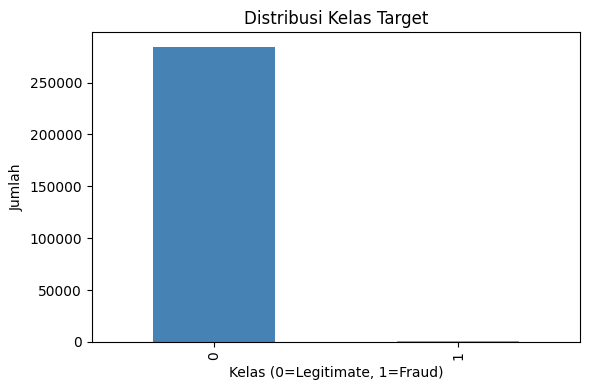

In [9]:
# Visualisasi distribusi kelas
fig, ax = plt.subplots(figsize=(6, 4))
df['target'].value_counts().plot(kind='bar', ax=ax, color=['steelblue', 'coral'])
ax.set_title('Distribusi Kelas Target')
ax.set_xlabel('Kelas (0=Legitimate, 1=Fraud)')
ax.set_ylabel('Jumlah')
plt.tight_layout()
plt.show()

In [10]:
# Korelasi fitur dengan target
corr_with_target = df.corr()['target'].drop('target').abs().sort_values(ascending=False)
print("Top 15 fitur berkorelasi dengan target:")
print(corr_with_target.head(15))

Top 15 fitur berkorelasi dengan target:
V17    0.326481
V14    0.302544
V12    0.260593
V10    0.216883
V16    0.196539
V3     0.192961
V7     0.187257
V11    0.154876
V4     0.133447
V18    0.111485
V1     0.101347
V9     0.097733
V5     0.094974
V2     0.091289
V6     0.043643
Name: target, dtype: float64


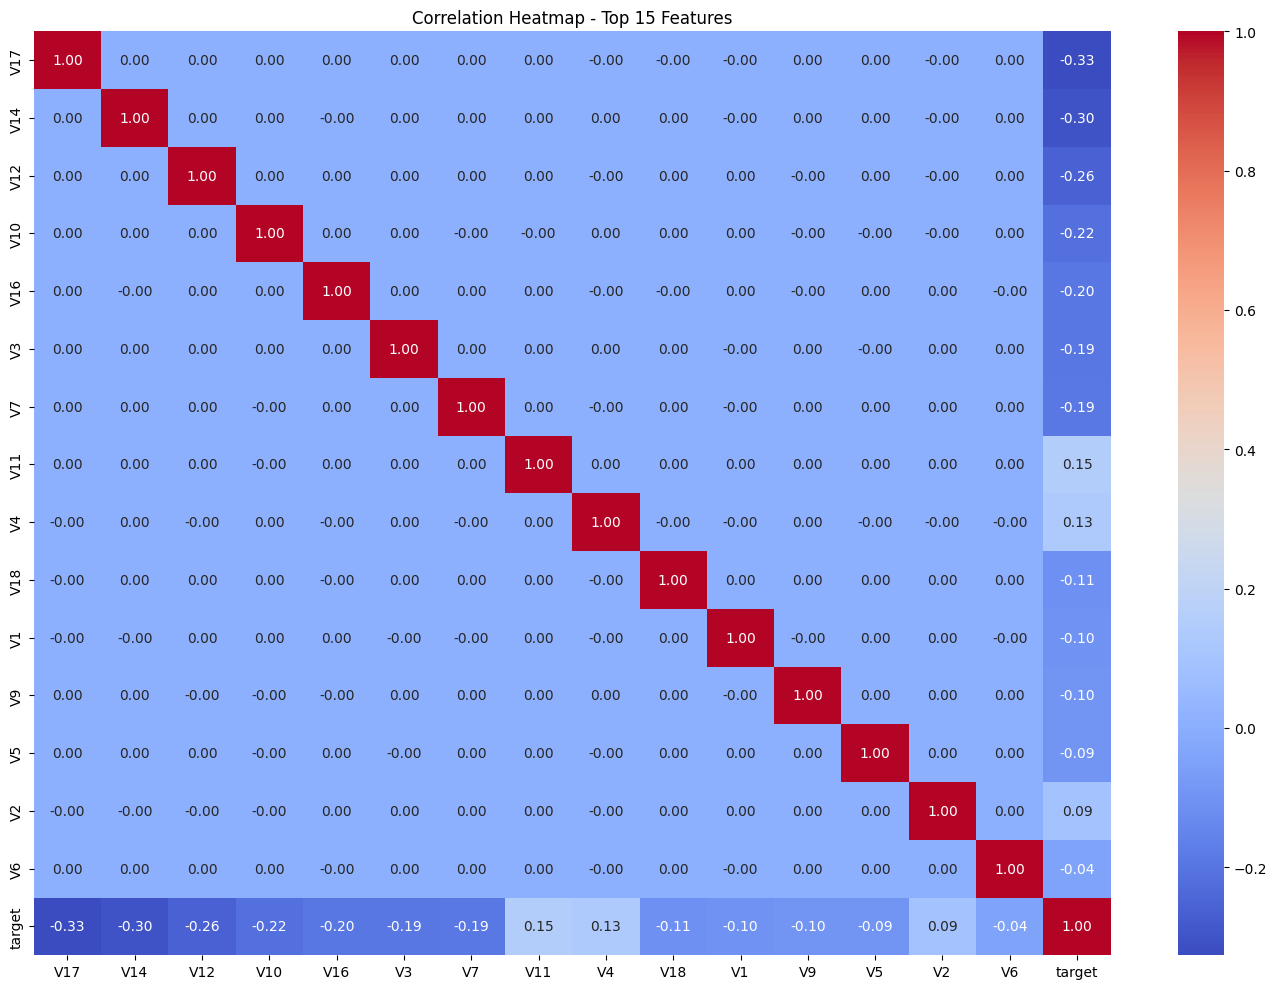

In [11]:
# Heatmap korelasi top 15 fitur + target
top_features = corr_with_target.head(15).index.tolist()
top_features.append('target')
plt.figure(figsize=(14, 10))
sns.heatmap(df[top_features].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap - Top 15 Features')
plt.tight_layout()
plt.show()

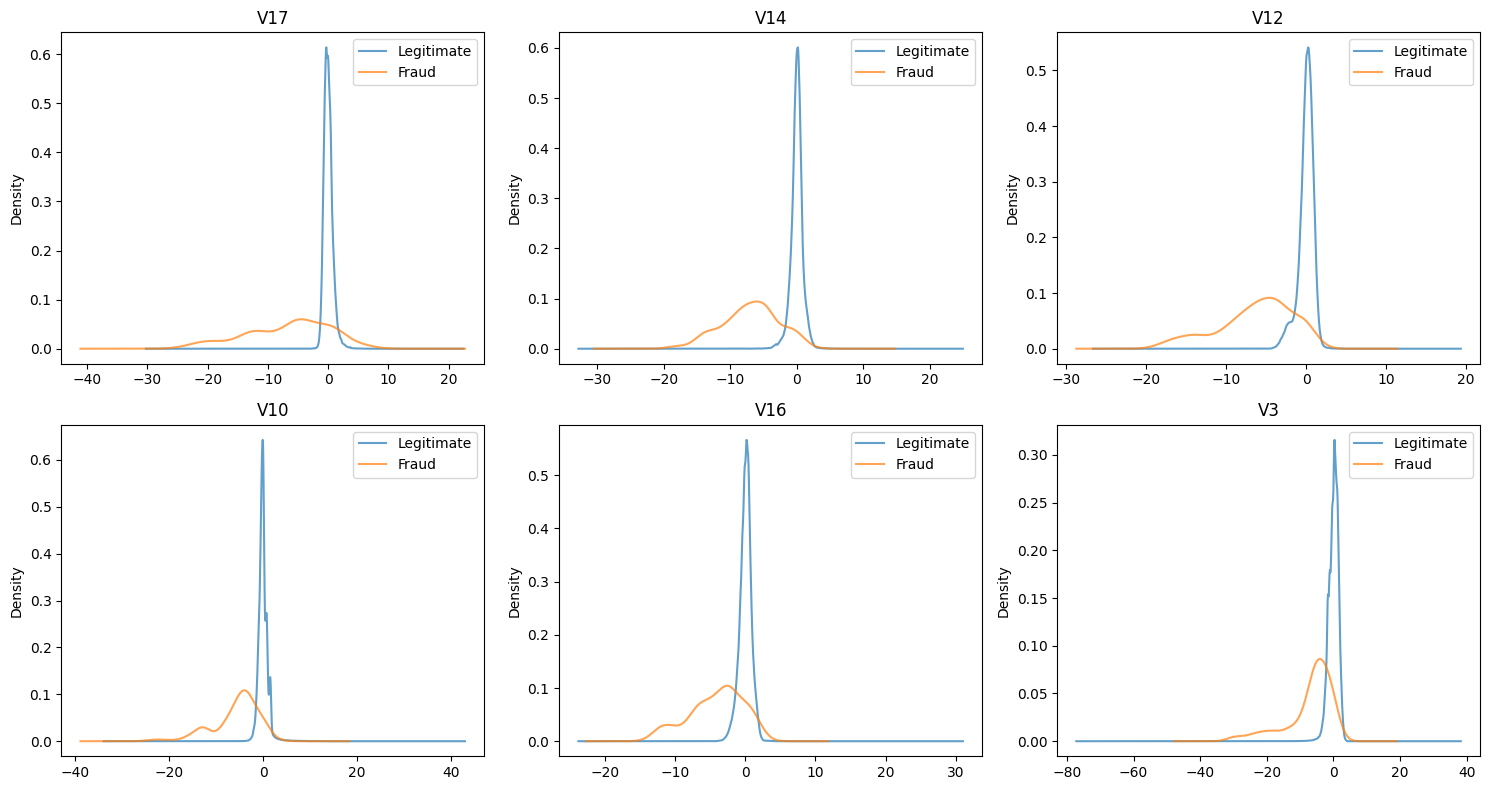

In [12]:
# Distribusi beberapa fitur terhadap target
top_6 = corr_with_target.head(6).index.tolist()
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, col in enumerate(top_6):
    ax = axes.flatten()[i]
    df[df['target']==0][col].plot(kind='kde', ax=ax, label='Legitimate', alpha=0.7)
    df[df['target']==1][col].plot(kind='kde', ax=ax, label='Fraud', alpha=0.7)
    ax.set_title(col)
    ax.legend()
plt.tight_layout()
plt.show()

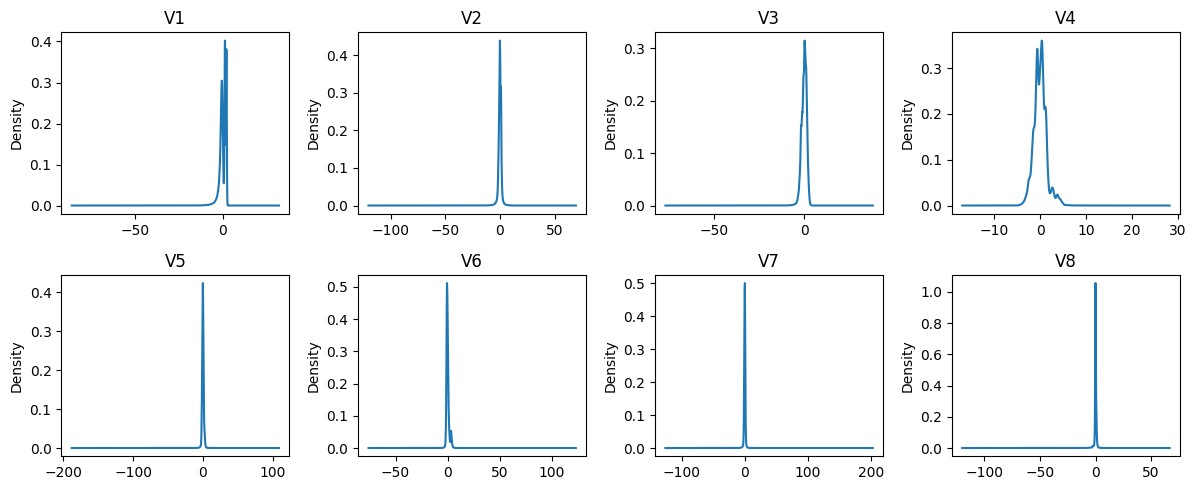

In [13]:
# Distribusi KDE beberapa fitur
sample_features = list(df.columns[:8])  # Ambil 8 fitur pertama
num_rows = 2
num_cols = 4

fig, ax = plt.subplots(num_rows, num_cols, figsize=(12, 5))

for i, column_name in enumerate(sample_features):
    df[column_name].plot(ax=ax.flatten()[i], kind='kde')
    ax.flatten()[i].set_title(column_name)

plt.tight_layout()
plt.show()

## Splitting Data

In [14]:
# DEFINE

minority_class = 1
X = df.loc[:, ~df.columns.isin(['target'])].values
y = df['target'].values

print(f"X shape: {X.shape}, y shape: {y.shape}")
print(f"Class distribution: {pd.Series(y).value_counts().to_dict()}")

X shape: (284807, 29), y shape: (284807,)
Class distribution: {0: 284315, 1: 492}


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y)

# ADASYN-Gaussian + Decision Tree

In [16]:
# Define the range of k values to test
k_values = range(2, 10)
beta_values = [0.5, 1.0, 1.5, 2.0]

# Run the evaluation (menggunakan X_train, y_train untuk menghindari data leakage)
results = evaluate_k(X_train, y_train, k_values, beta_values, minority_class=minority_class)

# Find the optimal k
best_k, best_beta, best_f1 = max(results, key=lambda item: item[2])

print(f'Optimal k: {best_k}, Optimal Beta: {best_beta}, F1 score: {best_f1:.4f}')

results

Optimal k: 8, Optimal Beta: 0.5, F1 score: 0.9991


[(2, 0.5, 0.9989675886132829),
 (2, 1.0, 0.9986538705611717),
 (2, 1.5, 0.9983683259097107),
 (2, 2.0, 0.9981442961091824),
 (3, 0.5, 0.9990733030333466),
 (3, 1.0, 0.9986970480929702),
 (3, 1.5, 0.9984371305535373),
 (3, 2.0, 0.998212031093601),
 (4, 0.5, 0.9991046841259564),
 (4, 1.0, 0.9987744750565142),
 (4, 1.5, 0.998495258337123),
 (4, 2.0, 0.9982775922422966),
 (5, 0.5, 0.9991302571627592),
 (5, 1.0, 0.9987914281488702),
 (5, 1.5, 0.9984548383196066),
 (5, 2.0, 0.9983331726847624),
 (6, 0.5, 0.9991131449840847),
 (6, 1.0, 0.9987849187571064),
 (6, 1.5, 0.9985434259416576),
 (6, 2.0, 0.9982711647033462),
 (7, 0.5, 0.9991151411532816),
 (7, 1.0, 0.9988097655174377),
 (7, 1.5, 0.9986335469516419),
 (7, 2.0, 0.998443025784908),
 (8, 0.5, 0.9991471722069495),
 (8, 1.0, 0.9988387959403563),
 (8, 1.5, 0.9985892952292402),
 (8, 2.0, 0.9984256294249627),
 (9, 0.5, 0.9991173822411256),
 (9, 1.0, 0.9988891522060881),
 (9, 1.5, 0.998583160214229),
 (9, 2.0, 0.9984663561130968)]

Proses Adasyn-Gaussian

In [17]:
# Menggunakan X_train, y_train untuk menghindari data leakage
X_synthetic, y_synthetic, synthetic_samples = adasyn_gaussian(X_train, y_train, k=best_k, beta=best_beta, minority_class=minority_class)
print(f"Menggunakan k={best_k}, beta={best_beta}")

Menggunakan k=8, beta=0.5


In [18]:
print("Data Sintetis yang Dihasilkan:")
print(synthetic_samples)

Data Sintetis yang Dihasilkan:
[[-4.11377495e+00  5.10763790e+00 -4.54558819e+00 ...  3.05992227e-01
  -2.10968136e-01 -3.88782694e+02]
 [-1.46135477e+00  3.26699260e-01  3.40621597e-01 ... -1.75552790e+00
   4.82146895e-01  3.39273052e+02]
 [-5.91309058e+00  5.11914857e+00 -1.02596227e+01 ... -2.30238537e-01
  -2.89643880e-01 -3.77426486e+02]
 ...
 [ 2.06055582e+00 -3.39829553e+00  5.75869638e+00 ...  5.61880557e-01
   9.29998020e-01  9.54624143e+01]
 [-1.06976479e+00  2.00605357e+00 -1.69949641e+00 ... -1.11599149e-01
   4.56495910e-01  1.43818568e+02]
 [-2.19782213e+00  9.91769766e-01 -5.33990872e+00 ... -1.68339996e-01
  -3.35271187e-01  2.95453243e+02]]


In [19]:
print("Jumlah Sampel Sintetis yang Dihasilkan:", len(synthetic_samples))

Jumlah Sampel Sintetis yang Dihasilkan: 99360


In [20]:
print("Jumlah Sampel di Kelas Minoritas Setelah Augmentasi:", sum(y_synthetic == minority_class))

Jumlah Sampel di Kelas Minoritas Setelah Augmentasi: 99704


In [21]:
select_column = df.loc[:, ~df.columns.isin(['target'])]
df_x = pd.DataFrame(X_train, columns=select_column.columns)
df_x

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,-0.882870,0.408028,1.675686,1.767672,-0.759701,0.136307,0.271356,-0.037380,0.415621,0.291596,...,-0.074056,0.121636,0.961607,-0.014062,0.382782,-0.466573,-0.138355,-0.348584,-0.398539,90.82
1,-1.527350,0.859043,0.142016,-1.144898,-0.526941,-0.646379,-0.386055,-0.649876,-1.208352,0.223122,...,-0.395352,1.090590,0.427869,0.023791,0.022254,0.122327,-0.179546,-0.715432,0.074606,25.00
2,1.957671,-0.365193,-0.388976,0.245661,-0.458577,-0.044011,-0.646763,0.177263,1.074679,0.014456,...,-0.226058,-0.140015,-0.337239,0.410102,0.705396,-0.458178,-0.676055,0.024346,-0.035212,2.49
3,0.142257,1.015441,-0.555185,-0.767313,1.218229,-0.254074,0.885876,0.041943,-0.336401,-0.674772,...,0.062986,-0.316101,-0.770471,0.017701,0.101659,-0.380362,0.120702,0.221517,0.070313,0.89
4,1.962787,0.473605,-2.291796,1.379738,1.066445,-0.647250,0.610595,-0.214028,-0.196947,-0.209210,...,-0.168535,0.026532,0.240876,-0.013277,0.592238,0.454597,-0.544568,-0.004562,-0.029156,19.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199359,2.362906,-0.509636,-2.883951,-1.113263,0.648281,-1.133065,0.361738,-0.521671,-0.859546,0.968041,...,-0.091300,0.409676,1.195349,-0.271797,0.106097,0.849328,0.314003,-0.107739,-0.096071,10.00
199360,1.261418,-0.654429,0.428917,0.002966,-0.964115,-0.317978,-0.464075,-0.104893,-0.491940,0.556901,...,-0.379192,-0.661506,-1.393988,0.049930,-0.130294,0.251611,0.312722,-0.008344,0.025418,64.95
199361,-0.566965,0.248249,1.040681,1.952279,-1.223061,0.305134,-0.006936,0.612848,-0.101202,-0.205177,...,0.276021,0.359857,0.935866,0.468367,0.557218,-1.122838,-0.297283,0.164883,0.178604,156.70
199362,-1.146691,1.100044,1.632327,-0.668578,0.342821,-0.690367,0.864338,-0.099466,-0.294566,-0.419913,...,-0.023620,-0.276511,-0.828824,-0.138557,-0.141219,0.347293,0.039219,-0.014781,0.101397,8.43


In [22]:
synthetic_df = pd.DataFrame(synthetic_samples, columns=df_x.columns)
synthetic_df

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,-4.113775,5.107638,-4.545588,1.867860,-0.547068,-0.922977,-5.260673,-2.243925,-0.910927,-2.847621,...,-1.407380,2.976123,-0.998645,0.631196,-0.070965,0.691433,-0.269619,0.305992,-0.210968,-388.782694
1,-1.461355,0.326699,0.340622,-0.707249,-5.394823,-1.217813,-2.518882,4.749095,1.524346,-4.183779,...,1.881759,-0.719563,0.861867,0.386158,0.553829,0.226331,0.120320,-1.755528,0.482147,339.273052
2,-5.913091,5.119149,-10.259623,2.914532,-4.886686,-2.756055,-7.275566,5.186183,-1.152729,-7.801302,...,-0.573320,2.727975,-1.259151,0.552815,-0.156240,1.267820,0.267008,-0.230239,-0.289644,-377.426486
3,3.450152,-0.404203,-1.590588,0.454947,0.280185,-1.580189,3.725772,5.185201,-0.315198,-0.940108,...,-0.389784,0.571809,0.301480,0.234106,-0.770816,0.442548,-0.217943,-0.586820,0.453802,21.773142
4,5.256026,-3.172792,7.491867,-1.658127,8.753601,0.645352,9.790052,-4.003542,2.920353,6.656601,...,1.116348,-1.455500,0.109875,0.866580,-0.624073,1.938092,0.369688,-1.164348,0.542723,29.597759
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99355,-9.820697,3.163592,-7.831052,0.209479,-7.520257,-1.759404,-6.250785,7.337549,-0.504733,-2.926554,...,0.147184,1.427679,0.243138,-1.110047,-0.241427,0.766022,-0.402487,-0.765195,0.109638,19.618630
99356,-6.892643,8.102246,-5.400952,5.671744,-4.458498,0.822284,-4.609412,-6.538336,-1.747658,-1.575825,...,0.052678,5.090350,-1.594651,4.100005,0.474230,-0.337346,0.670345,0.734530,1.493058,2.673821
99357,2.060556,-3.398296,5.758696,1.296746,6.552249,0.696764,6.880075,-0.955403,2.910620,8.636885,...,-2.001016,2.506511,-0.407889,-1.281154,0.020857,-0.433012,-0.037617,0.561881,0.929998,95.462414
99358,-1.069765,2.006054,-1.699496,6.002725,-2.627523,0.864616,-1.306264,1.025961,-3.460851,-3.408639,...,-1.149358,2.825333,0.348386,2.285109,0.271475,-0.569581,0.354377,-0.111599,0.456496,143.818568


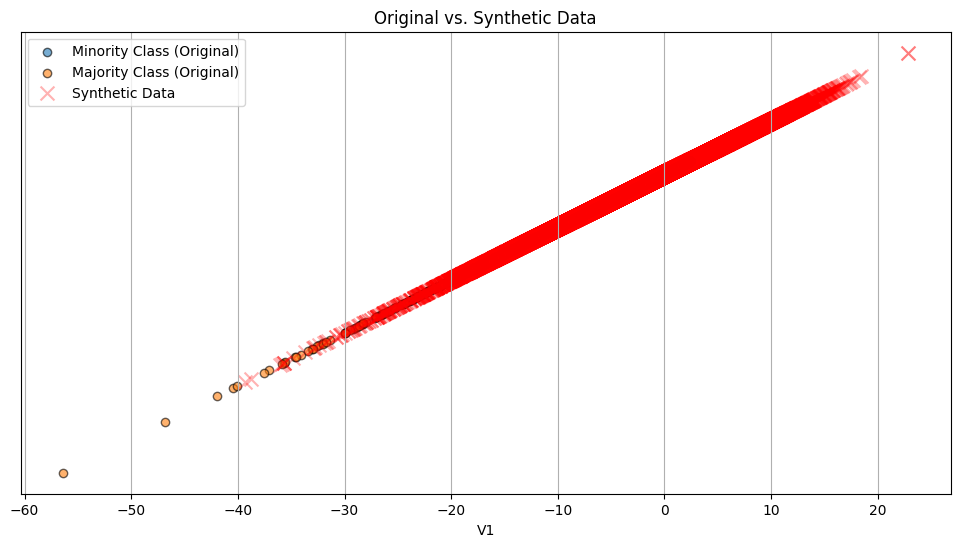

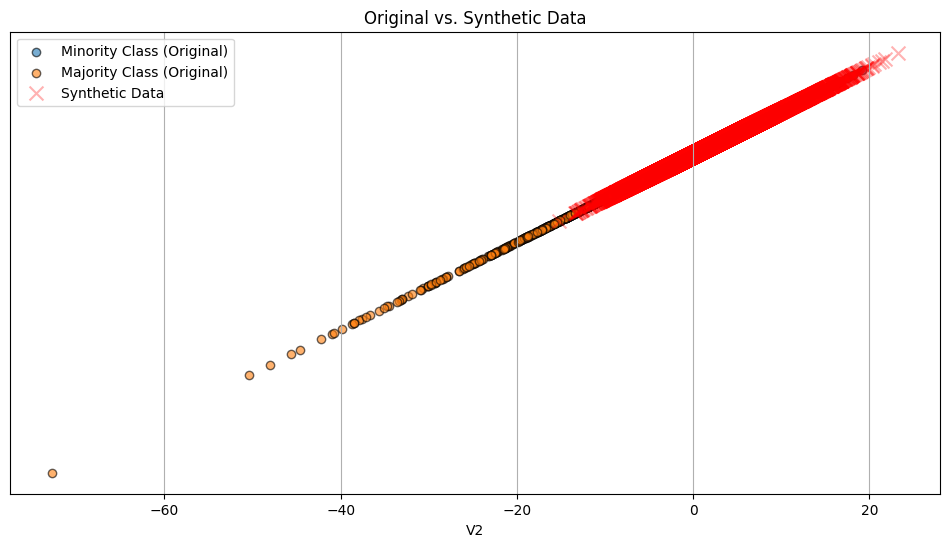

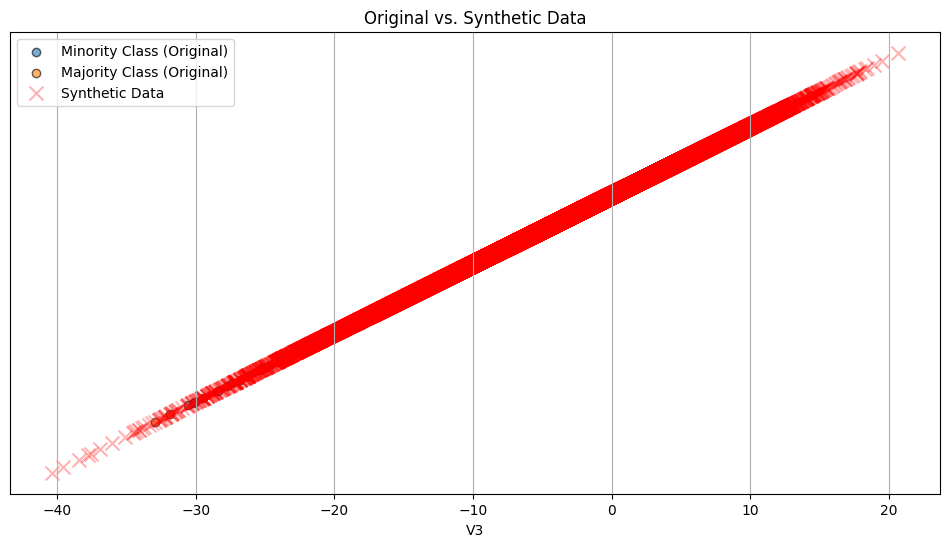

In [23]:
# Visualisasi Data Asli dan Sintetis
feature_names = select_column.columns.tolist()

def plot_synthetic_vs_original(X_train, y_train, synthetic_samples, feature_indices=0):
    plt.figure(figsize=(12, 6))
    
    # Plot data asli
    plt.scatter(X_train[y_train == 1, feature_indices], X_train[y_train == 1, feature_indices], label='Minority Class (Original)', alpha=0.6, edgecolor='k')
    plt.scatter(X_train[y_train == 0, feature_indices], X_train[y_train == 0, feature_indices], label='Majority Class (Original)', alpha=0.6, edgecolor='k')
    
    # Plot data sintetis
    plt.scatter(synthetic_samples[:, feature_indices], synthetic_samples[:, feature_indices], label='Synthetic Data', alpha=0.3, marker='x', color='r', s=100)
    
    plt.xlabel(feature_names[feature_indices])
    plt.yticks([])
    plt.title('Original vs. Synthetic Data')
    plt.legend()
    plt.grid(True)
    plt.show()

for feature_index in range(3):
    plot_synthetic_vs_original(X_train, y_train, synthetic_samples, feature_indices=feature_index)

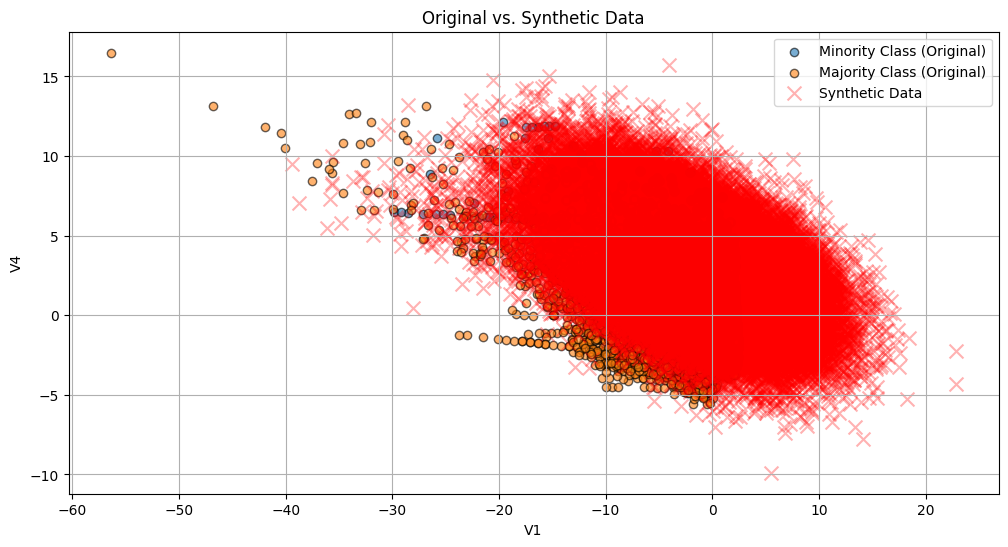

In [24]:
# Visualisasi Data Asli dan Sintetis (2D)
def plot_synthetic_vs_original_2d(X_train, y_train, synthetic_samples, feature_indices=[0, 1]):
    plt.figure(figsize=(12, 6))
    
    # Plot data asli
    plt.scatter(X_train[y_train == 1, feature_indices[0]], X_train[y_train== 1, feature_indices[1]], label='Minority Class (Original)', alpha=0.6, edgecolor='k')
    plt.scatter(X_train[y_train == 0, feature_indices[0]], X_train[y_train == 0, feature_indices[1]], label='Majority Class (Original)', alpha=0.6, edgecolor='k')
    
    # Plot data sintetis
    plt.scatter(synthetic_samples[:, feature_indices[0]], synthetic_samples[:, feature_indices[1]], label='Synthetic Data', alpha=0.3, s=100, marker='x', color='r')
    
    plt.xlabel(feature_names[feature_indices[0]])
    plt.ylabel(feature_names[feature_indices[1]])
    plt.title('Original vs. Synthetic Data')
    plt.legend()
    plt.grid(True)
    plt.show()

feature_indices = [0, 3]
plot_synthetic_vs_original_2d(X_train, y_train, synthetic_samples, feature_indices)

In [25]:
display(df_x.head(5), synthetic_df.head(5))

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,-0.882870,0.408028,1.675686,1.767672,-0.759701,0.136307,0.271356,-0.037380,0.415621,0.291596,...,-0.074056,0.121636,0.961607,-0.014062,0.382782,-0.466573,-0.138355,-0.348584,-0.398539,90.82
1,-1.527350,0.859043,0.142016,-1.144898,-0.526941,-0.646379,-0.386055,-0.649876,-1.208352,0.223122,...,-0.395352,1.090590,0.427869,0.023791,0.022254,0.122327,-0.179546,-0.715432,0.074606,25.00
2,1.957671,-0.365193,-0.388976,0.245661,-0.458577,-0.044011,-0.646763,0.177263,1.074679,0.014456,...,-0.226058,-0.140015,-0.337239,0.410102,0.705396,-0.458178,-0.676055,0.024346,-0.035212,2.49
3,0.142257,1.015441,-0.555185,-0.767313,1.218229,-0.254074,0.885876,0.041943,-0.336401,-0.674772,...,0.062986,-0.316101,-0.770471,0.017701,0.101659,-0.380362,0.120702,0.221517,0.070313,0.89
4,1.962787,0.473605,-2.291796,1.379738,1.066445,-0.647250,0.610595,-0.214028,-0.196947,-0.209210,...,-0.168535,0.026532,0.240876,-0.013277,0.592238,0.454597,-0.544568,-0.004562,-0.029156,19.04


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,-4.113775,5.107638,-4.545588,1.867860,-0.547068,-0.922977,-5.260673,-2.243925,-0.910927,-2.847621,...,-1.407380,2.976123,-0.998645,0.631196,-0.070965,0.691433,-0.269619,0.305992,-0.210968,-388.782694
1,-1.461355,0.326699,0.340622,-0.707249,-5.394823,-1.217813,-2.518882,4.749095,1.524346,-4.183779,...,1.881759,-0.719563,0.861867,0.386158,0.553829,0.226331,0.120320,-1.755528,0.482147,339.273052
2,-5.913091,5.119149,-10.259623,2.914532,-4.886686,-2.756055,-7.275566,5.186183,-1.152729,-7.801302,...,-0.573320,2.727975,-1.259151,0.552815,-0.156240,1.267820,0.267008,-0.230239,-0.289644,-377.426486
3,3.450152,-0.404203,-1.590588,0.454947,0.280185,-1.580189,3.725772,5.185201,-0.315198,-0.940108,...,-0.389784,0.571809,0.301480,0.234106,-0.770816,0.442548,-0.217943,-0.586820,0.453802,21.773142
4,5.256026,-3.172792,7.491867,-1.658127,8.753601,0.645352,9.790052,-4.003542,2.920353,6.656601,...,1.116348,-1.455500,0.109875,0.866580,-0.624073,1.938092,0.369688,-1.164348,0.542723,29.597759


In [26]:
synthetic_df['target'] = "Synthetic"
synthetic_df

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,target
0,-4.113775,5.107638,-4.545588,1.867860,-0.547068,-0.922977,-5.260673,-2.243925,-0.910927,-2.847621,...,2.976123,-0.998645,0.631196,-0.070965,0.691433,-0.269619,0.305992,-0.210968,-388.782694,Synthetic
1,-1.461355,0.326699,0.340622,-0.707249,-5.394823,-1.217813,-2.518882,4.749095,1.524346,-4.183779,...,-0.719563,0.861867,0.386158,0.553829,0.226331,0.120320,-1.755528,0.482147,339.273052,Synthetic
2,-5.913091,5.119149,-10.259623,2.914532,-4.886686,-2.756055,-7.275566,5.186183,-1.152729,-7.801302,...,2.727975,-1.259151,0.552815,-0.156240,1.267820,0.267008,-0.230239,-0.289644,-377.426486,Synthetic
3,3.450152,-0.404203,-1.590588,0.454947,0.280185,-1.580189,3.725772,5.185201,-0.315198,-0.940108,...,0.571809,0.301480,0.234106,-0.770816,0.442548,-0.217943,-0.586820,0.453802,21.773142,Synthetic
4,5.256026,-3.172792,7.491867,-1.658127,8.753601,0.645352,9.790052,-4.003542,2.920353,6.656601,...,-1.455500,0.109875,0.866580,-0.624073,1.938092,0.369688,-1.164348,0.542723,29.597759,Synthetic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99355,-9.820697,3.163592,-7.831052,0.209479,-7.520257,-1.759404,-6.250785,7.337549,-0.504733,-2.926554,...,1.427679,0.243138,-1.110047,-0.241427,0.766022,-0.402487,-0.765195,0.109638,19.618630,Synthetic
99356,-6.892643,8.102246,-5.400952,5.671744,-4.458498,0.822284,-4.609412,-6.538336,-1.747658,-1.575825,...,5.090350,-1.594651,4.100005,0.474230,-0.337346,0.670345,0.734530,1.493058,2.673821,Synthetic
99357,2.060556,-3.398296,5.758696,1.296746,6.552249,0.696764,6.880075,-0.955403,2.910620,8.636885,...,2.506511,-0.407889,-1.281154,0.020857,-0.433012,-0.037617,0.561881,0.929998,95.462414,Synthetic
99358,-1.069765,2.006054,-1.699496,6.002725,-2.627523,0.864616,-1.306264,1.025961,-3.460851,-3.408639,...,2.825333,0.348386,2.285109,0.271475,-0.569581,0.354377,-0.111599,0.456496,143.818568,Synthetic


In [27]:
# Data sintetis sudah siap (semua fitur numerik, tidak perlu konversi tipe)
synthetic_df.dtypes

V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
target     object
dtype: object

In [28]:
# Menggunakan data augmentasi langsung dari X_synthetic, y_synthetic
X_train_ag = X_synthetic
y_train_ag = y_synthetic

print(f"Training set size: {len(X_train_ag)}")
print(f"Test set size: {len(X_test)}")
print(f"Training class distribution: {pd.Series(y_train_ag).value_counts().to_dict()}")

Training set size: 298724
Test set size: 85443
Training class distribution: {0: 199020, 1: 99704}


In [29]:
# Distribusi kelas setelah augmentasi
print("Distribusi kelas training setelah ADASYN-Gaussian:")
print(pd.Series(y_train_ag).value_counts())

Distribusi kelas training setelah ADASYN-Gaussian:
0    199020
1     99704
Name: count, dtype: int64


In [30]:
# Info training data
print(f"X_train_ag shape: {X_train_ag.shape}")
print(f"y_train_ag shape: {y_train_ag.shape}")
print(f"X_test shape: {X_test.shape}")

X_train_ag shape: (298724, 29)
y_train_ag shape: (298724,)
X_test shape: (85443, 29)


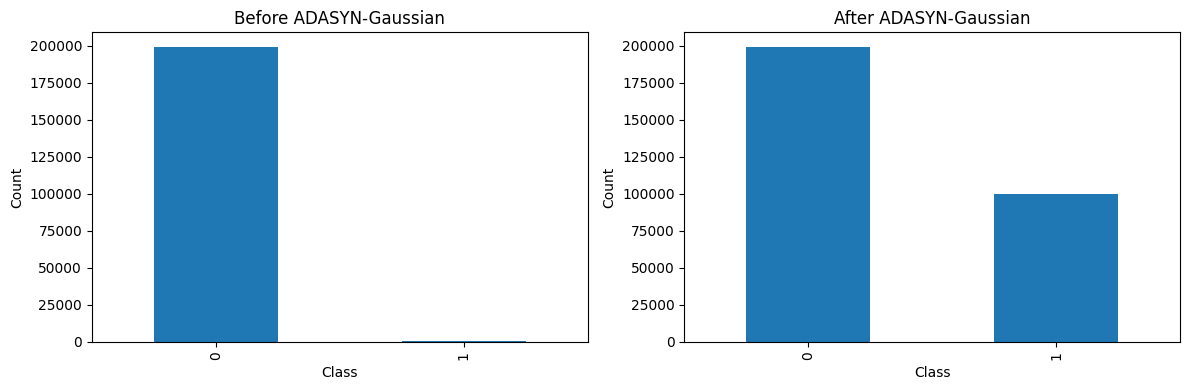

In [31]:
# Visualisasi distribusi kelas
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
pd.Series(y_train).value_counts().plot(kind='bar', ax=axes[0], title='Before ADASYN-Gaussian')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
pd.Series(y_train_ag).value_counts().plot(kind='bar', ax=axes[1], title='After ADASYN-Gaussian')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Count')
plt.tight_layout()
plt.show()

In [32]:
# Test set tetap menggunakan X_test, y_test dari train_test_split
X_test_ag = X_test
y_test_ag = y_test
print(f"X_test_ag shape: {X_test_ag.shape}")

X_test_ag shape: (85443, 29)


## Normalization

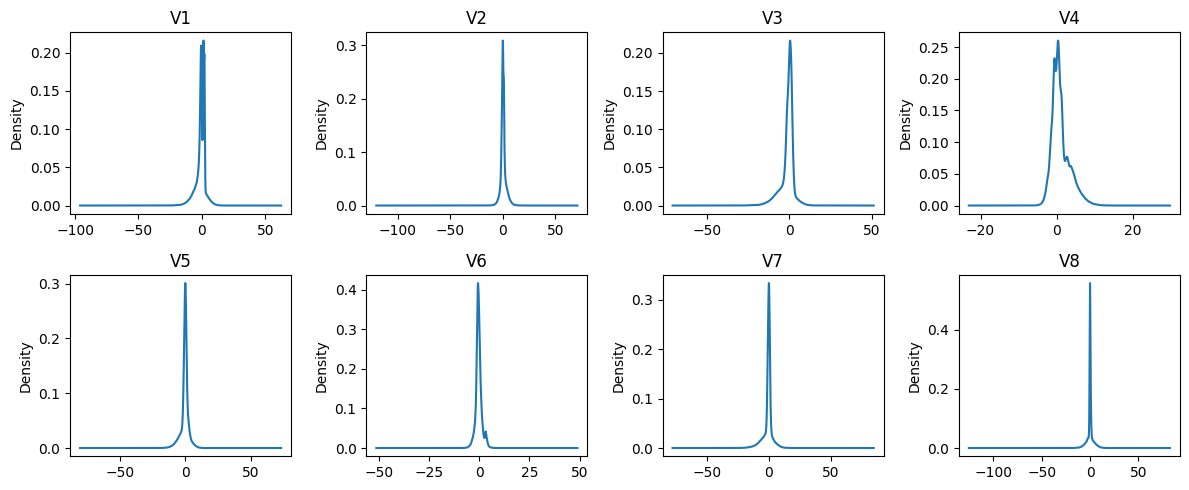

In [33]:
# Visualisasi distribusi fitur sebelum normalisasi (8 fitur pertama)
select_column = df.loc[:, ~df.columns.isin(['target'])]
df_train_viz = pd.DataFrame(X_train_ag, columns=select_column.columns)

sample_cols = list(df_train_viz.columns[:8])
num_rows = 2
num_cols = 4

fig, ax = plt.subplots(num_rows, num_cols, figsize=(12, 5))

for i, column_name in enumerate(sample_cols):
    df_train_viz[column_name].plot(ax=ax.flatten()[i], kind='kde')
    ax.flatten()[i].set_title(column_name)

plt.tight_layout()
plt.show()

In [34]:
# Pastikan y_train_ag adalah integer
y_train_ag = np.array(y_train_ag).astype(int)
y_test_ag = np.array(y_test_ag).astype(int)
print(f"y_train_ag dtype: {y_train_ag.dtype}, y_test_ag dtype: {y_test_ag.dtype}")

y_train_ag dtype: int64, y_test_ag dtype: int64


In [35]:
from sklearn.preprocessing import QuantileTransformer

n_samples = X_train_ag.shape[0]
transformer = QuantileTransformer(n_quantiles=min(n_samples, 1000), output_distribution='normal')

X_train_ag_scaled = transformer.fit_transform(X_train_ag)
X_test_ag_scaled = transformer.transform(X_test_ag)

print(f"X_train_ag_scaled shape: {X_train_ag_scaled.shape}")
print(f"X_test_ag_scaled shape: {X_test_ag_scaled.shape}")

X_train_ag_scaled shape: (298724, 29)
X_test_ag_scaled shape: (85443, 29)


## Classification

In [36]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (accuracy_score, classification_report, precision_score, 
                             recall_score, f1_score, roc_auc_score, roc_curve, 
                             confusion_matrix, ConfusionMatrixDisplay)

In [37]:
dt = DecisionTreeClassifier(random_state=42)

In [38]:
param_grid = {
    'max_depth': [10, 20, 30],        
    'min_samples_split': [2, 5, 10],  
    'min_samples_leaf': [1, 2, 4]   
}

# Initialize GridSearchCV
grid_search = GridSearchCV(dt, param_grid, cv=10, scoring='accuracy', verbose=2, n_jobs=-1)

# Fit the model
grid_search.fit(X_train_ag_scaled, y_train_ag)

Fitting 10 folds for each of 27 candidates, totalling 270 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, 20, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is display

In [39]:
# Get the best parameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_
print(f"Best Parameters: {best_params}")
print(f"Best Score: {best_score}")

Best Parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5}
Best Score: 0.9925114783811368


In [40]:
y_pred = grid_search.best_estimator_.predict(X_test_ag_scaled)

In [41]:
print("=== ADASYN-Gaussian + Decision Tree (Credit Card Fraud) ===")
print("Akurasi      :", accuracy_score(y_test_ag, y_pred))
print("Precision    :", precision_score(y_test_ag, y_pred))
print("Recall       :", recall_score(y_test_ag, y_pred))
print("F1 Score     :", f1_score(y_test_ag, y_pred))

=== ADASYN-Gaussian + Decision Tree (Credit Card Fraud) ===
Akurasi      : 0.9960090352632749
Precision    : 0.28018223234624146
Recall       : 0.831081081081081
F1 Score     : 0.4190800681431005


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.28      0.83      0.42       148

    accuracy                           1.00     85443
   macro avg       0.64      0.91      0.71     85443
weighted avg       1.00      1.00      1.00     85443



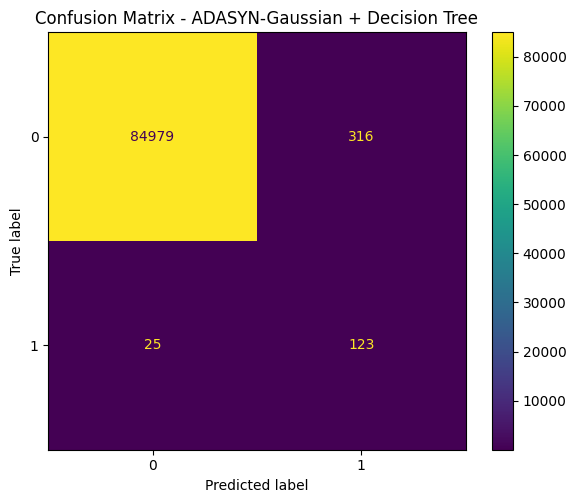

In [42]:
# Classification report
report = classification_report(y_test_ag, y_pred, zero_division=1)
print(report)

# Confusion Matrix
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test_ag, y_pred, ax=ax)
ax.set_title('Confusion Matrix - ADASYN-Gaussian + Decision Tree')
plt.tight_layout()
plt.show()

# ADASYN + Decision Tree

## ROC-AUC Curve - ADASYN-Gaussian + Decision Tree

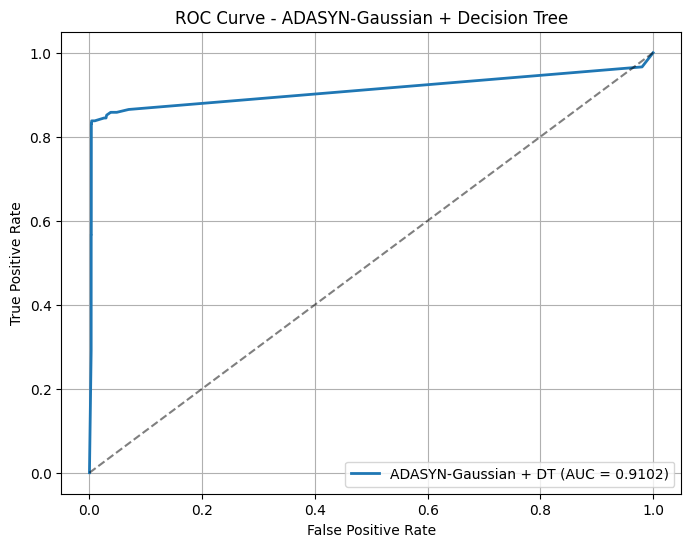

ROC-AUC Score: 0.9102


In [43]:
# ROC-AUC Curve untuk ADASYN-Gaussian + Decision Tree
y_prob_ag = grid_search.best_estimator_.predict_proba(X_test_ag_scaled)[:, 1]
fpr_ag, tpr_ag, _ = roc_curve(y_test_ag, y_prob_ag)
auc_ag = roc_auc_score(y_test_ag, y_prob_ag)

plt.figure(figsize=(8, 6))
plt.plot(fpr_ag, tpr_ag, label=f'ADASYN-Gaussian + DT (AUC = {auc_ag:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - ADASYN-Gaussian + Decision Tree')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f"ROC-AUC Score: {auc_ag:.4f}")

## Perbandingan Multiple Classifiers - ADASYN-Gaussian

In [44]:
# Perbandingan Multiple Classifiers dengan ADASYN-Gaussian
classifiers = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'DT (class_weight=balanced)': DecisionTreeClassifier(class_weight='balanced', random_state=42)
}

results_ag = []
roc_data_ag = {}

for name, clf in classifiers.items():
    print(f"Training {name}...")
    clf.fit(X_train_ag_scaled, y_train_ag)
    y_pred_clf = clf.predict(X_test_ag_scaled)
    y_prob_clf = clf.predict_proba(X_test_ag_scaled)[:, 1]
    
    acc = accuracy_score(y_test_ag, y_pred_clf)
    prec = precision_score(y_test_ag, y_pred_clf, zero_division=0)
    rec = recall_score(y_test_ag, y_pred_clf, zero_division=0)
    f1 = f1_score(y_test_ag, y_pred_clf, zero_division=0)
    auc = roc_auc_score(y_test_ag, y_prob_clf)
    
    results_ag.append({
        'Model': name,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1 Score': round(f1, 4),
        'ROC-AUC': round(auc, 4)
    })
    
    fpr_clf, tpr_clf, _ = roc_curve(y_test_ag, y_prob_clf)
    roc_data_ag[name] = (fpr_clf, tpr_clf, auc)

results_ag_df = pd.DataFrame(results_ag).sort_values('F1 Score', ascending=False)
print("\n=== Hasil Perbandingan Classifiers dengan ADASYN-Gaussian ===")
display(results_ag_df)

Training Decision Tree...
Training Random Forest...
Training Gradient Boosting...
Training SVM...
Training Logistic Regression...
Training DT (class_weight=balanced)...

=== Hasil Perbandingan Classifiers dengan ADASYN-Gaussian ===


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
3,SVM,0.9990,0.6742,0.8108,0.7362,0.9543
1,Random Forest,0.9988,0.6124,0.8649,0.7171,0.9544
2,Gradient Boosting,0.9972,0.3675,0.8243,0.5083,0.9552
0,Decision Tree,0.9945,0.2162,0.8311,0.3431,0.9129
5,DT (class_weight=balanced),0.9941,0.2050,0.8311,0.3289,0.9127
4,Logistic Regression,0.9614,0.0389,0.8986,0.0746,0.9725


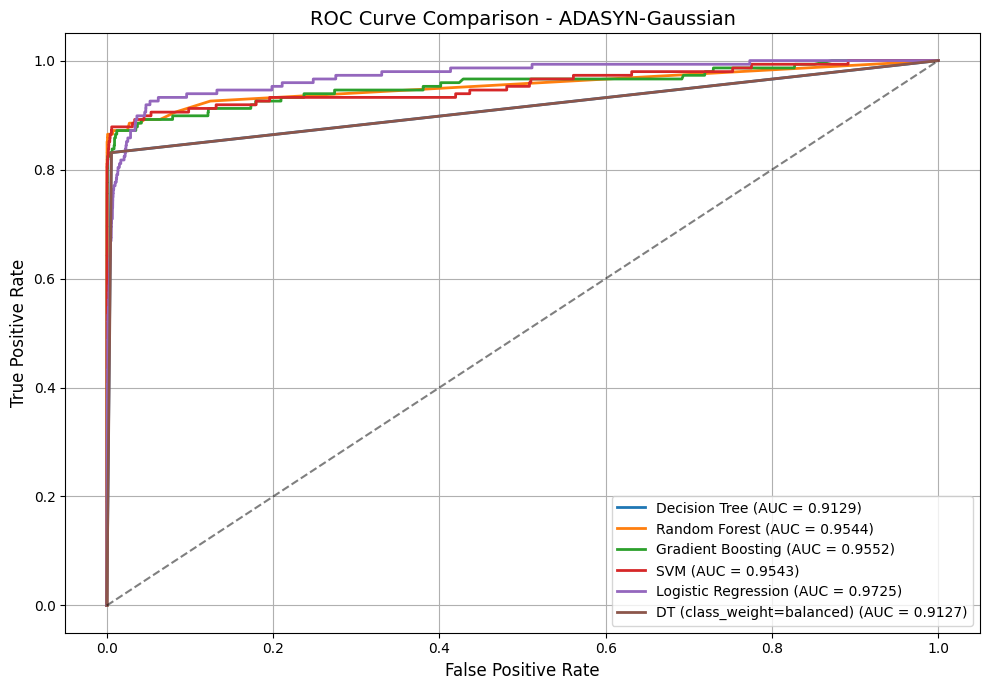

In [45]:
# ROC Curve Comparison - Semua Classifiers (ADASYN-Gaussian)
plt.figure(figsize=(10, 7))
for name, (fpr_clf, tpr_clf, auc_clf) in roc_data_ag.items():
    plt.plot(fpr_clf, tpr_clf, label=f'{name} (AUC = {auc_clf:.4f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve Comparison - ADASYN-Gaussian', fontsize=14)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True)
plt.tight_layout()
plt.show()

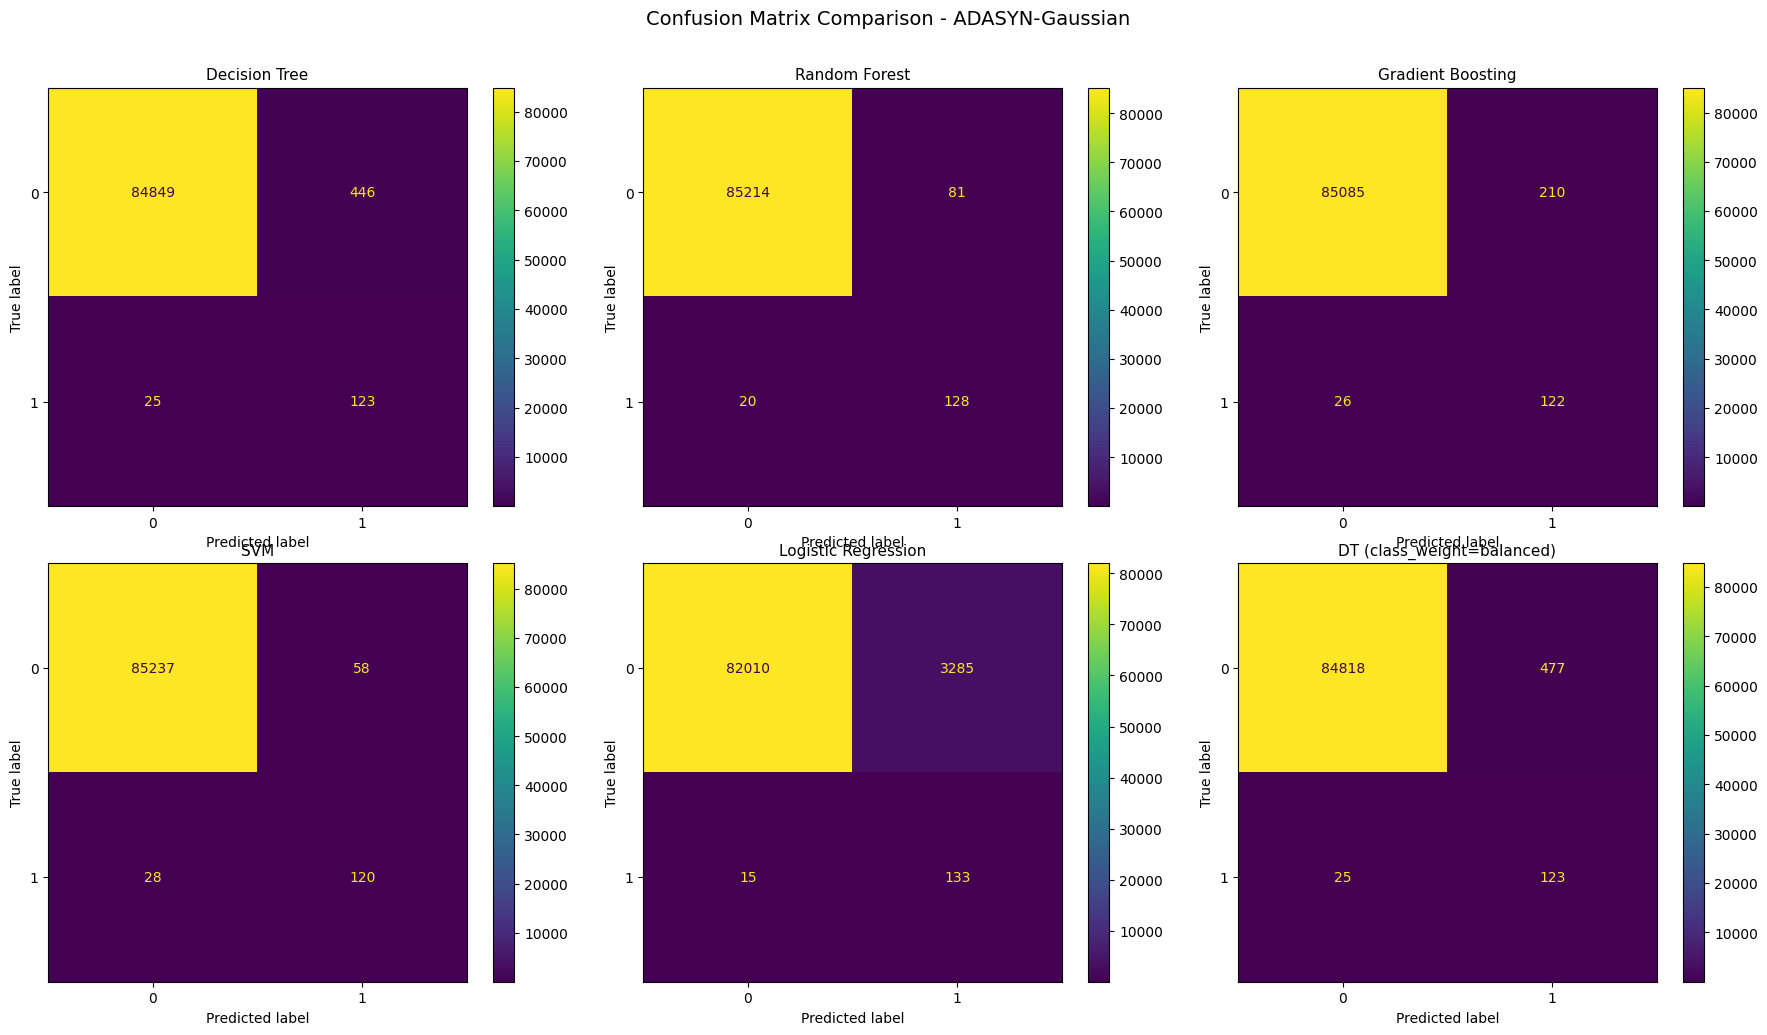

In [46]:
# Confusion Matrix Comparison - Semua Classifiers (ADASYN-Gaussian)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for idx, (name, clf) in enumerate(classifiers.items()):
    y_pred_clf = clf.predict(X_test_ag_scaled)
    ax = axes.flatten()[idx]
    ConfusionMatrixDisplay.from_predictions(y_test_ag, y_pred_clf, ax=ax)
    ax.set_title(f'{name}', fontsize=11)

plt.suptitle('Confusion Matrix Comparison - ADASYN-Gaussian', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## ADASYN

In [47]:
# (Sudah diimport dengan try/except di cell sebelumnya)

In [48]:
from imblearn.over_sampling import ADASYN 
from collections import Counter

In [49]:
# Check class distribution before augmentation
print(f'Original class distribution: {Counter(y_train)}')

Original class distribution: Counter({np.int64(0): 199020, np.int64(1): 344})


In [50]:
# Tuning n_neighbors untuk ADASYN
from collections import Counter

best_adasyn_f1 = 0
best_adasyn_n = 2
best_X_res = None
best_y_res = None

for n_neighbors in [2, 3, 5, 7]:
    try:
        adasyn_temp = ADASYN(sampling_strategy='minority', n_neighbors=n_neighbors, random_state=42)
        X_res_temp, y_res_temp = adasyn_temp.fit_resample(X_train, y_train)
        
        # Quick evaluation with Decision Tree
        dt_temp = DecisionTreeClassifier(random_state=42)
        dt_temp.fit(X_res_temp, y_res_temp)
        y_pred_temp = dt_temp.predict(X_test)
        f1_temp = f1_score(y_test, y_pred_temp, zero_division=0)
        
        print(f"n_neighbors={n_neighbors}: distribution={Counter(y_res_temp)}, F1={f1_temp:.4f}")
        
        if f1_temp > best_adasyn_f1:
            best_adasyn_f1 = f1_temp
            best_adasyn_n = n_neighbors
            best_X_res = X_res_temp
            best_y_res = y_res_temp
    except Exception as e:
        print(f"n_neighbors={n_neighbors}: Error - {e}")

print(f"\nBest n_neighbors: {best_adasyn_n} with F1: {best_adasyn_f1:.4f}")

# Gunakan hasil terbaik
X_resampled = best_X_res
y_resampled = best_y_res

n_neighbors=2: distribution=Counter({np.int64(0): 199020, np.int64(1): 199004}), F1=0.6250
n_neighbors=3: distribution=Counter({np.int64(0): 199020, np.int64(1): 198982}), F1=0.6167
n_neighbors=5: distribution=Counter({np.int64(1): 199091, np.int64(0): 199020}), F1=0.5485
n_neighbors=7: distribution=Counter({np.int64(0): 199020, np.int64(1): 198989}), F1=0.4880

Best n_neighbors: 2 with F1: 0.6250


In [51]:
# Check class distribution after augmentation
print(f'Resampled class distribution (n_neighbors={best_adasyn_n}): {Counter(y_resampled)}')

Resampled class distribution (n_neighbors=2): Counter({np.int64(0): 199020, np.int64(1): 199004})


In [52]:
n_samples = X_resampled.shape[0]
transformer = QuantileTransformer(n_quantiles=min(n_samples, 1000), output_distribution='normal')

X_resampled_scaled = transformer.fit_transform(X_resampled)
X_test_scaled2 = transformer.transform(X_test)

In [53]:
param_grid = {
    'max_depth': [10, 20, 30],        
    'min_samples_split': [2, 5, 10],  
    'min_samples_leaf': [1, 2, 4]   
}

# Initialize GridSearchCV
grid_search = GridSearchCV(dt, param_grid, cv=10, scoring='accuracy', verbose=2, n_jobs=-1)

# Fit the model
grid_search.fit(X_resampled_scaled, y_resampled)

Fitting 10 folds for each of 27 candidates, totalling 270 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, 20, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is display

In [54]:
# Get the best parameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_
print(f"Best Parameters: {best_params}")
print(f"Best Score: {best_score}")

Best Parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best Score: 0.9616557974081342


In [55]:
y_pred = grid_search.best_estimator_.predict(X_test_scaled2)

In [56]:
print("=== Standard ADASYN + Decision Tree (Credit Card Fraud) ===")
print("Akurasi      :", accuracy_score(y_test, y_pred))
print("Precision    :", precision_score(y_test, y_pred))
print("Recall       :", recall_score(y_test, y_pred))
print("F1 Score     :", f1_score(y_test, y_pred))

=== Standard ADASYN + Decision Tree (Credit Card Fraud) ===
Akurasi      : 0.9951195533864682
Precision    : 0.23046092184368738
Recall       : 0.777027027027027
F1 Score     : 0.3554868624420402


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.23      0.78      0.36       148

    accuracy                           1.00     85443
   macro avg       0.62      0.89      0.68     85443
weighted avg       1.00      1.00      1.00     85443



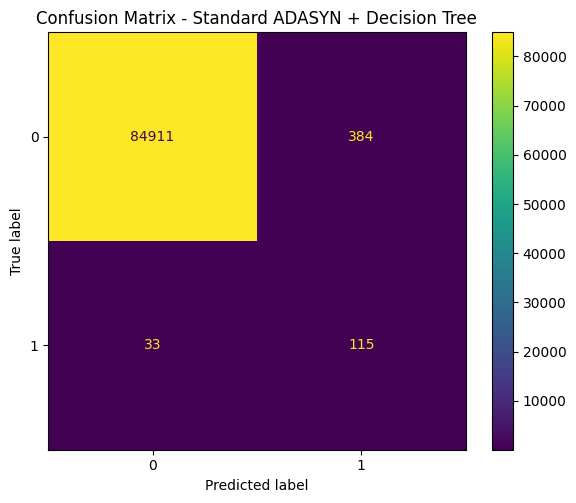

In [57]:
# Classification report
report = classification_report(y_test, y_pred, zero_division=1)
print(report)

# Confusion Matrix
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax)
ax.set_title('Confusion Matrix - Standard ADASYN + Decision Tree')
plt.tight_layout()
plt.show()

In [58]:
# Perbandingan Multiple Classifiers dengan Standard ADASYN
classifiers_adasyn = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'DT (class_weight=balanced)': DecisionTreeClassifier(class_weight='balanced', random_state=42)
}

results_adasyn = []
roc_data_adasyn = {}

for name, clf in classifiers_adasyn.items():
    print(f"Training {name}...")
    clf.fit(X_resampled_scaled, y_resampled)
    y_pred_clf = clf.predict(X_test_scaled2)
    y_prob_clf = clf.predict_proba(X_test_scaled2)[:, 1]
    
    acc = accuracy_score(y_test, y_pred_clf)
    prec = precision_score(y_test, y_pred_clf, zero_division=0)
    rec = recall_score(y_test, y_pred_clf, zero_division=0)
    f1 = f1_score(y_test, y_pred_clf, zero_division=0)
    auc = roc_auc_score(y_test, y_prob_clf)
    
    results_adasyn.append({
        'Model': name,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1 Score': round(f1, 4),
        'ROC-AUC': round(auc, 4)
    })
    
    fpr_clf, tpr_clf, _ = roc_curve(y_test, y_prob_clf)
    roc_data_adasyn[name] = (fpr_clf, tpr_clf, auc)

results_adasyn_df = pd.DataFrame(results_adasyn).sort_values('F1 Score', ascending=False)
print("\n=== Hasil Perbandingan Classifiers dengan Standard ADASYN ===")
display(results_adasyn_df)

Training Decision Tree...
Training Random Forest...
Training Gradient Boosting...
Training SVM...
Training Logistic Regression...
Training DT (class_weight=balanced)...

=== Hasil Perbandingan Classifiers dengan Standard ADASYN ===


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
1,Random Forest,0.9995,0.9008,0.7973,0.8459,0.9487
3,SVM,0.9988,0.6284,0.7770,0.6949,0.9502
0,Decision Tree,0.9985,0.5441,0.7500,0.6307,0.8745
5,DT (class_weight=balanced),0.9985,0.5427,0.7297,0.6225,0.8643
2,Gradient Boosting,0.9856,0.0981,0.8919,0.1768,0.9777
4,Logistic Regression,0.9515,0.0318,0.9189,0.0616,0.9723


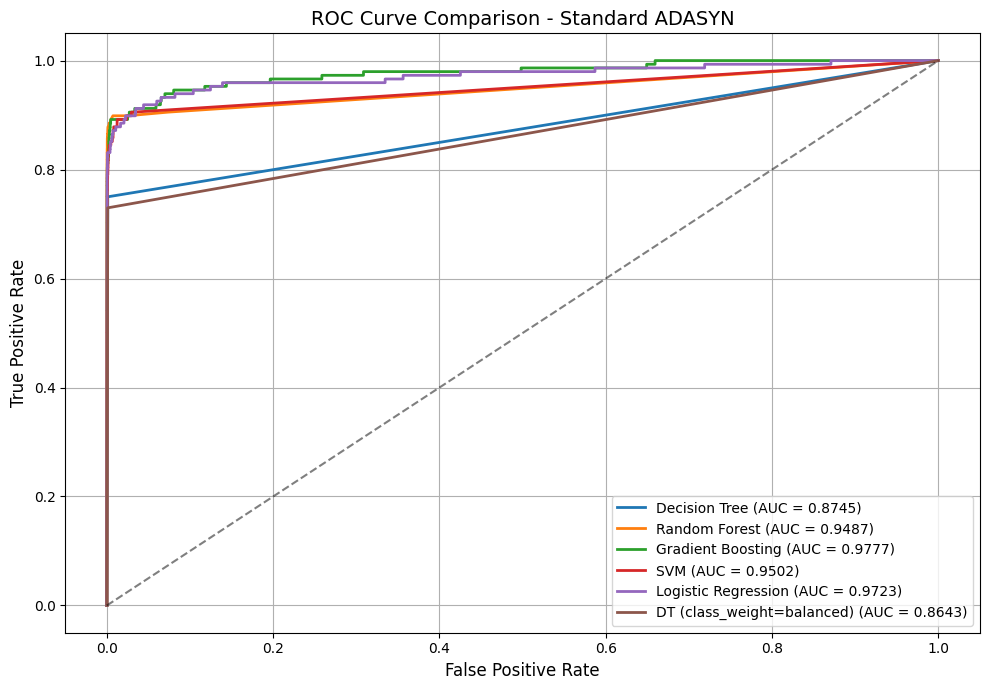

In [59]:
# ROC Curve Comparison - Semua Classifiers (Standard ADASYN)
plt.figure(figsize=(10, 7))
for name, (fpr_clf, tpr_clf, auc_clf) in roc_data_adasyn.items():
    plt.plot(fpr_clf, tpr_clf, label=f'{name} (AUC = {auc_clf:.4f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve Comparison - Standard ADASYN', fontsize=14)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True)
plt.tight_layout()
plt.show()

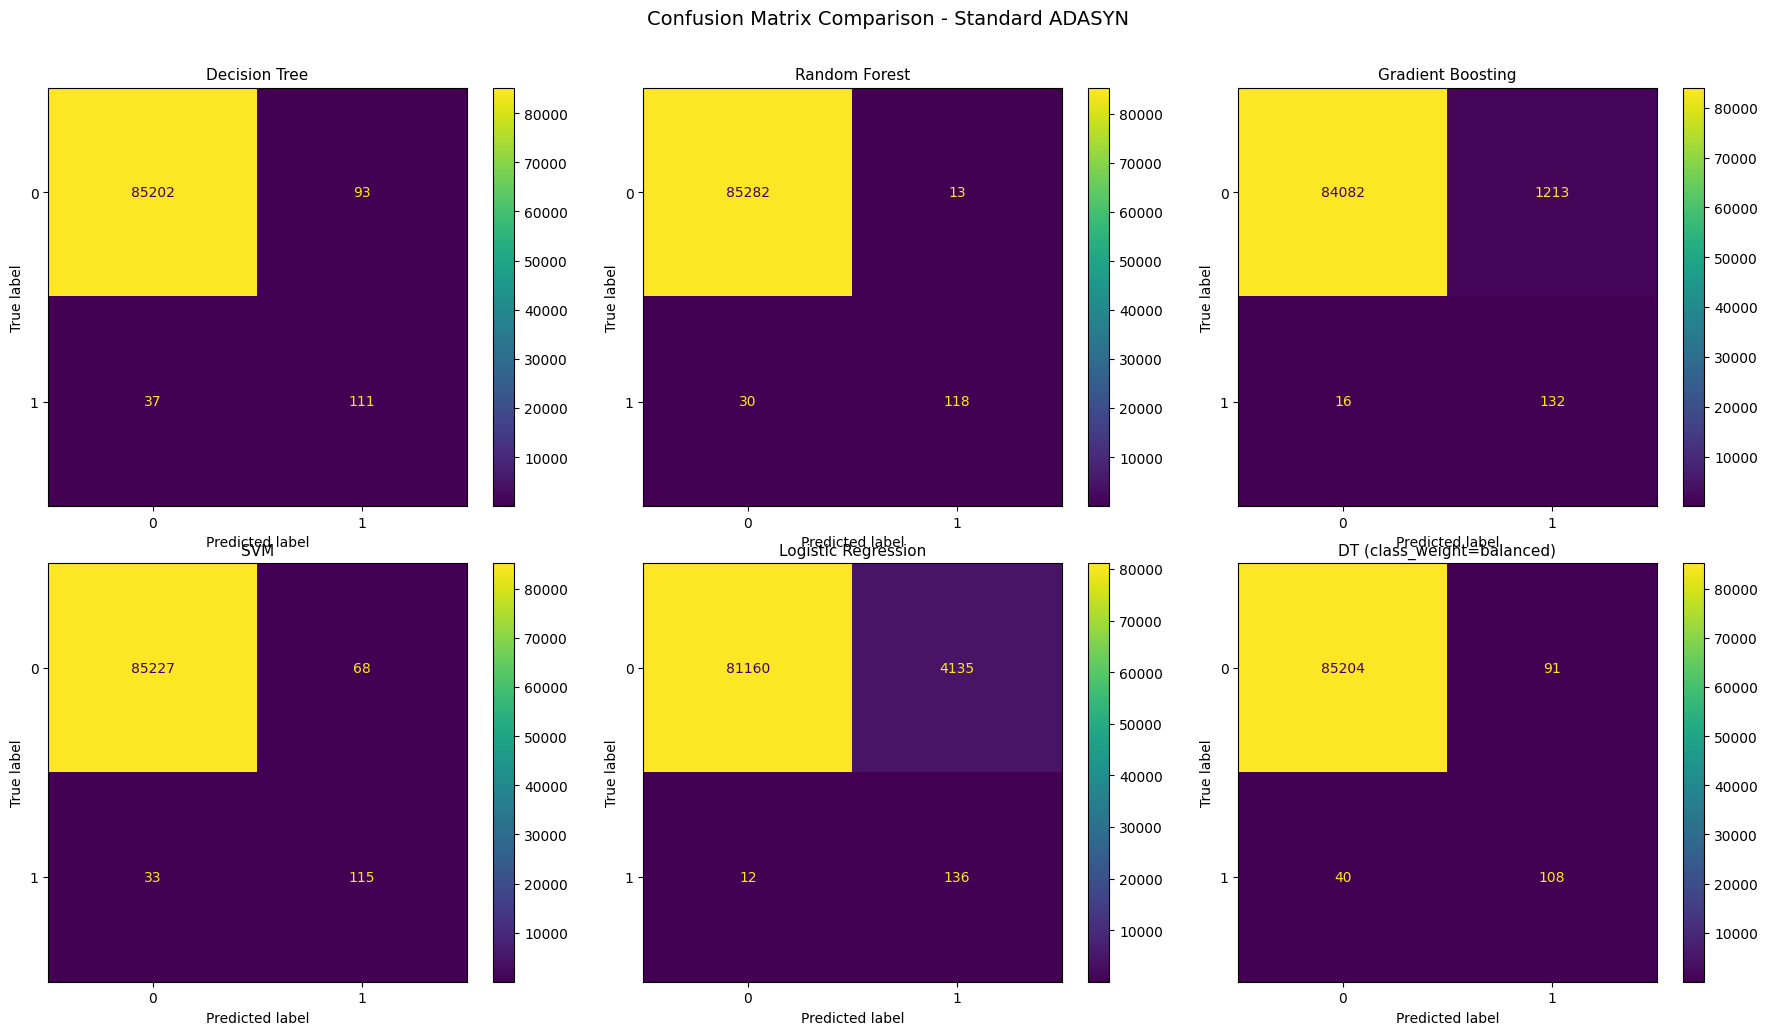

In [60]:
# Confusion Matrix Comparison - Semua Classifiers (Standard ADASYN)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for idx, (name, clf) in enumerate(classifiers_adasyn.items()):
    y_pred_clf = clf.predict(X_test_scaled2)
    ax = axes.flatten()[idx]
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred_clf, ax=ax)
    ax.set_title(f'{name}', fontsize=11)

plt.suptitle('Confusion Matrix Comparison - Standard ADASYN', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Perbandingan Akhir: ADASYN-Gaussian vs Standard ADASYN

In [61]:
# Tabel Perbandingan ADASYN-Gaussian vs Standard ADASYN
results_ag_df['Method'] = 'ADASYN-Gaussian'
results_adasyn_df['Method'] = 'Standard ADASYN'

comparison_df = pd.concat([results_ag_df, results_adasyn_df], ignore_index=True)
comparison_df = comparison_df[['Method', 'Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']]
comparison_df = comparison_df.sort_values(['Model', 'Method'])

print("=== Perbandingan Akhir: ADASYN-Gaussian vs Standard ADASYN ===")
display(comparison_df)

# Highlight best F1 per method
print("\n--- Best Model per Method ---")
for method in ['ADASYN-Gaussian', 'Standard ADASYN']:
    best = comparison_df[comparison_df['Method'] == method].sort_values('F1 Score', ascending=False).iloc[0]
    print(f"{method}: {best['Model']} (F1={best['F1 Score']}, AUC={best['ROC-AUC']})")

=== Perbandingan Akhir: ADASYN-Gaussian vs Standard ADASYN ===


,Method,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
4,ADASYN-Gaussian,DT (class_weight=balanced),0.9941,0.2050,0.8311,0.3289,0.9127
9,Standard ADASYN,DT (class_weight=balanced),0.9985,0.5427,0.7297,0.6225,0.8643
3,ADASYN-Gaussian,Decision Tree,0.9945,0.2162,0.8311,0.3431,0.9129
8,Standard ADASYN,Decision Tree,0.9985,0.5441,0.7500,0.6307,0.8745
2,ADASYN-Gaussian,Gradient Boosting,0.9972,0.3675,0.8243,0.5083,0.9552
10,Standard ADASYN,Gradient Boosting,0.9856,0.0981,0.8919,0.1768,0.9777
5,ADASYN-Gaussian,Logistic Regression,0.9614,0.0389,0.8986,0.0746,0.9725
11,Standard ADASYN,Logistic Regression,0.9515,0.0318,0.9189,0.0616,0.9723
1,ADASYN-Gaussian,Random Forest,0.9988,0.6124,0.8649,0.7171,0.9544
6,Standard ADASYN,Random Forest,0.9995,0.9008,0.7973,0.8459,0.9487



--- Best Model per Method ---
ADASYN-Gaussian: SVM (F1=0.7362, AUC=0.9543)
Standard ADASYN: Random Forest (F1=0.8459, AUC=0.9487)


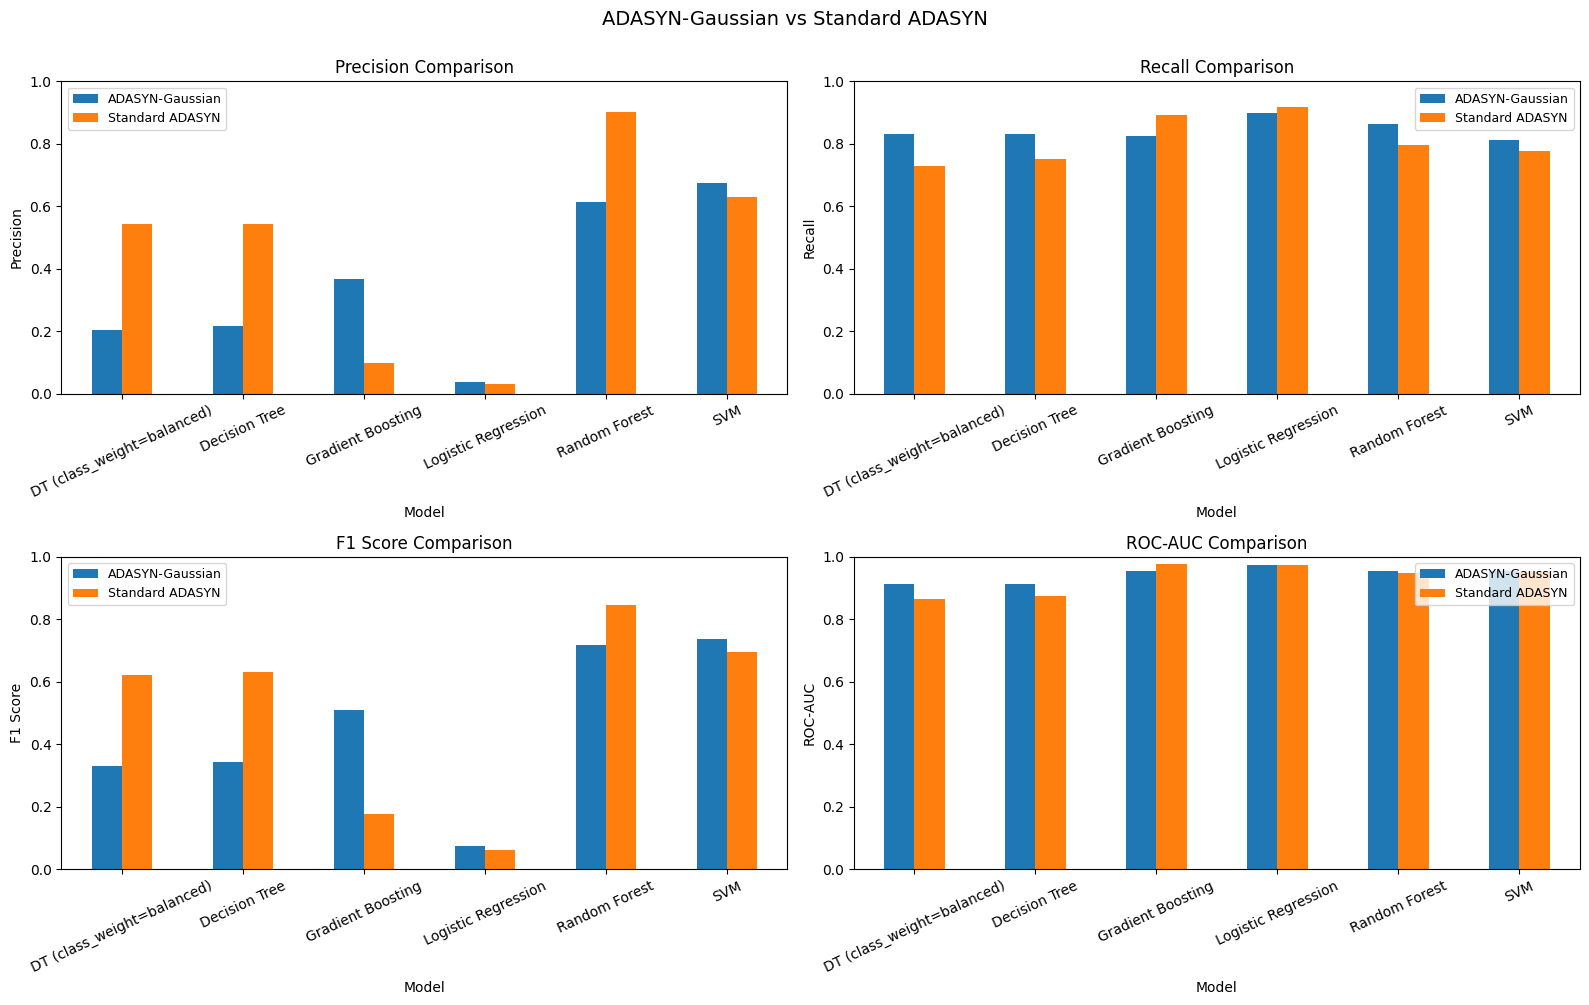

In [62]:
# Visualisasi Bar Chart Perbandingan dengan Precision
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

metrics_to_plot = ['Precision', 'Recall', 'F1 Score', 'ROC-AUC']
for i, metric in enumerate(metrics_to_plot):
    ax = axes.flatten()[i]
    pivot = comparison_df.pivot(index='Model', columns='Method', values=metric)
    pivot.plot(kind='bar', ax=ax, rot=25)
    ax.set_title(f'{metric} Comparison', fontsize=12)
    ax.set_ylabel(metric)
    ax.legend(fontsize=9)
    ax.set_ylim(0, 1)

plt.suptitle('ADASYN-Gaussian vs Standard ADASYN', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()